# EXAMEN I — ANÁLISIS DE ACCIDENTES DE TRÁFICO EN ECUADOR

## Tecnología Superior en Desarrollo de Software

### Asignatura: Análisis de Datos

---

|                            |            |
| -------------------------- | ---------- |
| **Nombre del estudiante:** |     Alan Javier Reyes Casierra       |
| **Fecha:**                 |      28/5/2026      |
| **Tiempo disponible:**     | 3 horas    |
| **Puntaje total:**         | 100 puntos |


## 📋 INSTRUCCIONES GENERALES

- Complete **únicamente** las celdas de código y las celdas Markdown habilitadas con `✏️ Tu respuesta:`.
- Los archivos de datos se encuentran en la carpeta **`data/`** ubicada en el mismo directorio que este notebook.
- Todos los gráficos deben incluir **título** y **etiquetas en los ejes**.

> ⚠️ Los datos corresponden a registros **simulados** de accidentes de tráfico del Ecuador (2019 – 2023),
> distribuidos por región geográfica en distintos formatos de archivo.


## 📁 DESCRIPCIÓN DE LOS ARCHIVOS Y COLUMNAS

Los datos provienen de distintas fuentes del sistema de registro de la **Agencia Nacional de Tránsito (ANT) del Ecuador**.

### Columnas del dataset

| Columna                  | Tipo           | Descripción                                                      |
| ------------------------ | -------------- | ---------------------------------------------------------------- |
| `id_accidente`           | int            | Identificador único del registro                                 |
| `fecha`                  | str → datetime | Fecha del accidente (`YYYY-MM-DD`)                               |
| `provincia`              | str            | Provincia donde ocurrió el accidente                             |
| `canton`                 | str            | Cantón dentro de la provincia                                    |
| `tipo_accidente`         | str            | Tipo de accidente (Choque frontal, Atropello, Volcamiento, etc.) |
| `causa_probable`         | str            | Causa probable del accidente                                     |
| `gravedad`               | str            | Nivel de gravedad: `Leve`, `Grave`, `Fatal`                      |
| `victimas_fatales`       | float          | Número de víctimas mortales                                      |
| `heridos`                | float          | Número de heridos                                                |
| `vehiculos_involucrados` | float          | Vehículos involucrados                                           |
| `condicion_climatica`    | str            | Condición climática al momento del hecho                         |
| `tipo_via`               | str            | Tipo de vía: Urbana, Rural, Autopista, etc.                      |

### Archivos disponibles en `data/`

| Archivo                        | Formato                                                    | Región cubierta                        |
| ------------------------------ | ---------------------------------------------------------- | -------------------------------------- |
| `accidentes_costa.csv`         | CSV                                                        | Guayas, Manabí, El Oro, Los Ríos       |
| `accidentes_sierra.xlsx`       | Excel                                                      | Pichincha, Azuay, Tungurahua, Imbabura |
| `accidentes.json`              | Fuente de diferentes regiones con datos en estructura JSON | Loja, Cotopaxi, Chimborazo, Bolívar    |
| `accidentes_amazonia.sqlite`   | SQLite                                                     | Sucumbíos, Napo, Orellana              |
| `accidentes_feriados.xml`      | XML                                                        | Todo Ecuador — solo días festivos      |
| `accidentes_insularMongo.json` | MONGO                                                      | Region Insular                         |


---

# PARTE 1: EXTRACCIÓN DE DATOS _(15 puntos)_


## 1.1 Importar librerías


In [215]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Cargar desde CSV _(2 pts)_

Cargue `data/accidentes_costa.csv` a un Dataframe. Agregue la columna `origen = 'CSV'`.
Muestre la cantidad de registros cargados.


In [216]:
# Su código aquí
df_csv = pd.read_csv('./data/accidentes_costa.csv')
df_csv['origen'] = 'CSV'

print(f'{len(df_csv)} registros cargados desde ./data/accidentes_costa.csv')

df_csv.head(5)

232 registros cargados desde ./data/accidentes_costa.csv


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,1,2019-07-11,Guayas,Daule,Choque lateral,Estado de embriaguez,Leve,NaN,4.0,1.0,Soleado,NaN,CSV
1,2,2019-07-29,Manabi,Portoviejo,Volcamiento,Distraccion del conductor,Fatal,5.0,7.0,1.0,Soleado,Autopista,CSV
2,3,2022-12-13,El Oro,Machala,Choque frontal,Fallas mecanicas,Grave,1.0,0.0,4.0,Lluvioso,Rural,CSV
3,4,2022-06-01,El Oro,Pasaje,Rozamiento,Cansancio del conductor,Grave,0.0,1.0,3.0,Lluvioso,Urbana,CSV
4,5,2021-04-01,Manabi,Chone,Choque frontal,No respetar seniales,Leve,0.0,4.0,2.0,Lluvioso,Autopista,CSV


## 1.3 Cargar desde Excel _(2 pts)_

Cargue `data/accidentes_sierra.xlsx` a un Dataframe. Agregue la columna `origen = 'EXCEL'`.
Muestre la cantidad de registros cargados.


In [217]:
# Su código aquí
df_excel = pd.read_excel('./data/accidentes_sierra.xlsx')
df_excel['origen'] = 'EXCEL'

print(f'{len(df_excel)} registros cargados desde ./data/accidentes_sierra.xlsx')

df_excel.head(5)

90 registros cargados desde ./data/accidentes_sierra.xlsx


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,830,2019-07-03,Galapagos,Espanola,Rozamiento,Estado de embriaguez,Grave,1.0,1.0,1.0,Neblina,Secundaria,EXCEL
1,831,2023-10-07,Galapagos,San Cristobal,Rozamiento,No respetar seniales,Leve,0.0,4.0,2.0,Nublado,Rural,EXCEL
2,832,2020-02-10,Galapagos,Santa Cruz,Rozamiento,Mal estado de la via,Grave,0.0,NaN,NaN,Neblina,Secundaria,EXCEL
3,833,2021-10-27,Galapagos,Santa Cruz,Caida de ocupante,Mal estado de la via,Leve,0.0,1.0,3.0,Lluvioso,Rural,EXCEL
4,834,2019-01-12,Galapagos,Santa Cruz,Volcamiento,Exceso de velocidad,Grave,NaN,3.0,2.0,Nublado,Secundaria,EXCEL


## 1.4 Cargar desde JSON — simula una API _(2 pts)_

Cargue `data/accidentes.json` a un Dataframe.

> **Pista:** Los registros están dentro de la clave `"data"` del JSON.

Agregue la columna `origen = 'JSON_API'`. Muestre la cantidad de registros cargados.


In [218]:
# Su código aquí
import json

with open('./data/accidentes.json') as f:
    data = json.load(f)

df_api = pd.DataFrame(data['data'])
df_api['origen'] = 'JSON_API'

print(f'{len(df_api)} registros cargados desde ./data/accidentes.json [data]')

df_api.head(5)

160 registros cargados desde ./data/accidentes.json [data]


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,421,2021-12-07,Bolivar,San Miguel,Choque lateral,Estado de embriaguez,Grave,1,1,4,Nublado,Secundaria,JSON_API
1,422,2019-06-09,Loja,Loja,Choque con objeto fijo,Estado de embriaguez,Grave,2,3,2,Neblina,Urbana,JSON_API
2,423,2023-03-26,Bolivar,Guaranda,Choque con objeto fijo,,Leve,,,1,Soleado,Urbana,JSON_API
3,424,2023-10-18,Cotopaxi,Salcedo,Choque con objeto fijo,Mal estado de la via,Leve,0,3,1,Lluvioso,Rural,JSON_API
4,425,2021-10-29,Loja,Calvas,Atropello,,Leve,0,0,3,Lluvioso,Rural,JSON_API


## 1.5 Cargar desde SQLite _(2 pts)_

Conéctese a `data/accidentes_amazonia.sqlite` y lea la tabla `accidentes_amazonia` cargue los datos a un Dataframe .
Agregue la columna `origen = 'SQLITE'`. Muestre la cantidad de registros cargados.


In [219]:
# Su código aquí
import sqlite3

con_sqlite = sqlite3.connect('./data/accidentes_amazonia.sqlite')
df_sqlite = pd.read_sql('select * from accidentes_amazonia', con_sqlite)
con_sqlite.close()

df_sqlite['origen'] = 'SQLITE'

print(f'{len(df_sqlite)} registros cargados desde la BD (SQLite) -> ./data/accidentes_amazonia.sqlite')

df_sqlite.head(5)

232 registros cargados desde la BD (SQLite) -> ./data/accidentes_amazonia.sqlite

,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,1,2019-07-11,Guayas,Daule,Choque lateral,Estado de embriaguez,Leve,NaN,4.0,1.0,Soleado,NaN,SQLITE
1,2,2019-07-29,Manabi,Portoviejo,Volcamiento,Distraccion del conductor,Fatal,5.0,7.0,1.0,Soleado,Autopista,SQLITE
2,3,2022-12-13,El Oro,Machala,Choque frontal,Fallas mecanicas,Grave,1.0,0.0,4.0,Lluvioso,Rural,SQLITE
3,4,2022-06-01,El Oro,Pasaje,Rozamiento,Cansancio del conductor,Grave,0.0,1.0,3.0,Lluvioso,Urbana,SQLITE
4,5,2021-04-01,Manabi,Chone,Choque frontal,No respetar seniales,Leve,0.0,4.0,2.0,Lluvioso,Autopista,SQLITE


## 1.6 Cargar desde XML _(2 pts)_

Cargue `data/accidentes_feriados.xml` usando `xml.etree.ElementTree` a un Dataframe.

> 💡 **Pista:** Cada registro está en una etiqueta `<accidente>`.

Agregue la columna `origen = 'XML'`. Muestre la cantidad de registros cargados.


In [220]:
# Su código aquí
df_xml = pd.read_xml('./data/accidentes_feriados.xml', xpath='accidente')
df_xml['origen'] = 'XML'

print(f'{len(df_xml)} registros cargados desde ./data/accidentes_feriados.xml <accidente>')

df_xml.head(5)

130 registros cargados desde ./data/accidentes_feriados.xml <accidente>


,id,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,nombre_feriado,origen
0,701,2019-08-10,Orellana,Loreto,Volcamiento,No respetar seniales,Leve,0.0,4.0,4.0,Soleado,Autopista,Independencia de Quito,XML
1,702,2021-10-09,Sucumbios,Nueva Loja,Choque frontal,Mal estado de la via,Leve,0.0,0.0,4.0,Soleado,Rural,Independencia de Guayaquil,XML
2,703,2022-10-12,Imbabura,Ibarra,Rozamiento,NaN,Leve,0.0,5.0,NaN,Neblina,Rural,Dia de la Raza,XML
3,704,2022-05-24,Guayas,Daule,Atropello,Mal estado de la via,Leve,0.0,6.0,4.0,Neblina,Autopista,Batalla de Pichincha,XML
4,705,2023-04-08,Orellana,Loreto,Atropello,Exceso de velocidad,Leve,NaN,35.0,15.0,Soleado,Rural,Semana Santa,XML


## 1.7 Cargar desde MONGO DB _(2 pts)_

Cargue `data/accidentes_insularMongo.json` a MONGO DB y luego realize una conexión para la extracción de datos desde Mongo  
Tip: El documento envoltorio que tiene los accidentes anidados es el campo `data` , tomar en cuenta para poder extraer correctamente del anidamiento

Los datos extraidos almacenelos en un DataFrame y agregue la columna `origen = 'MONGO'`. Muestre la cantidad de registros cargados.


In [221]:
from pymongo import MongoClient

con_mongo = MongoClient('mongodb://localhost:27017/')

db = con_mongo['Examen']
coleccion = db['Examen']

doc = coleccion.find_one({'data.provincia': 'Galapagos'})

df_mongo = pd.DataFrame(doc['data'])

df_mongo['origen'] = 'MONGO'

print(f'{len(df_mongo)} registros cargados desde MongoDB [MONGO]')

df_mongo.head(5)

90 registros cargados desde MongoDB [MONGO]


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,830,2019-07-03,Galapagos,Espanola,Rozamiento,Estado de embriaguez,Grave,1,1,1,Neblina,Secundaria,MONGO
1,831,2023-10-07,Galapagos,San Cristobal,Rozamiento,No respetar seniales,Leve,0,4,2,Nublado,Rural,MONGO
2,832,2020-02-10,Galapagos,Santa Cruz,Rozamiento,Mal estado de la via,Grave,0,,,Neblina,Secundaria,MONGO
3,833,2021-10-27,Galapagos,Santa Cruz,Caida de ocupante,Mal estado de la via,Leve,0,1,3,Lluvioso,Rural,MONGO
4,834,2019-01-12,Galapagos,Santa Cruz,Volcamiento,Exceso de velocidad,Grave,,3,2,Nublado,Secundaria,MONGO


## 1.8 Concatenar todas las fuentes _(3 pts)_

Una todos los DataFrames en **`df_accidentes`** usando `pd.concat()` con `ignore_index=True`.
Muestre el total de registros y cuántos vinieron de cada fuente (`value_counts` sobre `origen`).


In [222]:
# Su código aquí
df_accidentes = pd.concat([
    df_csv,
    df_excel,
    df_api,
    df_sqlite,
    df_xml,
    df_mongo
], ignore_index=True)

print(f'Total de registros: {len(df_accidentes)}')

display(df_accidentes.value_counts('origen'))

Total de registros: 934


origen
CSV         232
SQLITE      232
JSON_API    160
XML         130
EXCEL        90
MONGO        90
Name: count, dtype: int64

---

# PARTE 2: ANÁLISIS EXPLORATORIO INICIAL _(10 puntos)_


## 2.1 Estructura del dataset _(3 pts)_

Muestre: número de filas y columnas, tipos de datos de cada columna y las primeras 5 filas.


In [223]:
# Su código aquí
print('Filas, Columnas')
print(f' {df_accidentes.shape}')

print('\n           === TIPOS DE DATOS ===')
print(df_accidentes.info())

df_accidentes.head(5)

Filas, Columnas
 (934, 15)

           === TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_accidente            804 non-null    float64
 1   fecha                   934 non-null    str    
 2   provincia               934 non-null    str    
 3   canton                  934 non-null    str    
 4   tipo_accidente          934 non-null    str    
 5   causa_probable          879 non-null    str    
 6   gravedad                934 non-null    str    
 7   victimas_fatales        884 non-null    object 
 8   heridos                 899 non-null    object 
 9   vehiculos_involucrados  915 non-null    object 
 10  condicion_climatica     934 non-null    str    
 11  tipo_via                884 non-null    str    
 12  origen                  934 non-null    str    
 13  id                      130 non-null    floa

,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen,id,nombre_feriado
0,1.0,2019-07-11,Guayas,Daule,Choque lateral,Estado de embriaguez,Leve,NaN,4.0,1.0,Soleado,NaN,CSV,NaN,NaN
1,2.0,2019-07-29,Manabi,Portoviejo,Volcamiento,Distraccion del conductor,Fatal,5.0,7.0,1.0,Soleado,Autopista,CSV,NaN,NaN
2,3.0,2022-12-13,El Oro,Machala,Choque frontal,Fallas mecanicas,Grave,1.0,0.0,4.0,Lluvioso,Rural,CSV,NaN,NaN
3,4.0,2022-06-01,El Oro,Pasaje,Rozamiento,Cansancio del conductor,Grave,0.0,1.0,3.0,Lluvioso,Urbana,CSV,NaN,NaN
4,5.0,2021-04-01,Manabi,Chone,Choque frontal,No respetar seniales,Leve,0.0,4.0,2.0,Lluvioso,Autopista,CSV,NaN,NaN


In [224]:
df_accidentes = df_accidentes.drop(columns=['id'])

## 2.2 Estadísticas descriptivas _(2 pts)_

Muestre `describe()` para variables numéricas **y** categóricas.


In [225]:
# Su código aquí
# variables numéricas
print('VARIABLES NUMÉRICAS')
display(df_accidentes.describe())

#variables categóricas
print('VARIABLES CATEGÓRICAS (include="all")')
display(df_accidentes.describe(include='all'))

VARIABLES NUMÉRICAS


,id_accidente
count,804.000000
mean,356.850746
std,321.491740
min,1.000000
25%,89.000000
50%,189.500000
75%,559.250000
max,919.000000


VARIABLES CATEGÓRICAS (include="all")


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen,nombre_feriado
count,804.000000,934,934,934,934,879,934,884.0,899.0,915.0,934,884,934,130
unique,NaN,443,16,71,7,8,3,7.0,17.0,11.0,4,6,6,11
top,NaN,2023-10-09,Galapagos,San Cristobal,Choque frontal,Estado de embriaguez,Leve,0.0,5.0,1.0,Neblina,Urbana,CSV,Carnaval
freq,NaN,9,180,50,153,147,515,560.0,113.0,252.0,248,180,232,24
mean,356.850746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,321.491740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,89.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,189.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,559.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.3 Análisis de valores nulos _(2 pts)_

Muestre el número **y** porcentaje de nulos por columna.
Ordene el resultado de mayor a menor porcentaje de nulos.


In [226]:
# Su código aquí
print('  === CANTIDAD DE NULOS ===')
display(df_accidentes.isnull().sum().sort_values(ascending=False))

print('\n  === PORCENTAJE DE NULOS ===')
display(round(df_accidentes.isnull().sum() / len(df_accidentes) * 100, 2).sort_values(ascending=False))

  === CANTIDAD DE NULOS ===


nombre_feriado            804
id_accidente              130
causa_probable             55
victimas_fatales           50
tipo_via                   50
heridos                    35
vehiculos_involucrados     19
canton                      0
provincia                   0
fecha                       0
tipo_accidente              0
gravedad                    0
condicion_climatica         0
origen                      0
dtype: int64


  === PORCENTAJE DE NULOS ===


nombre_feriado            86.08
id_accidente              13.92
causa_probable             5.89
victimas_fatales           5.35
tipo_via                   5.35
heridos                    3.75
vehiculos_involucrados     2.03
canton                     0.00
provincia                  0.00
fecha                      0.00
tipo_accidente             0.00
gravedad                   0.00
condicion_climatica        0.00
origen                     0.00
dtype: float64

## 2.4 Manejo de fechas _(3 pts)_

1. Convierta la columna `fecha` a tipo `datetime` con `pd.to_datetime()`.
2. Extraiga el **año** en la columna `anio`.
3. Extraiga el **mes** en la columna `mes`.
4. Extraiga el **día de la semana** en la columna `dia_semana` (0 = Lunes, 6 = Domingo).

Muestre las nuevas columnas con `.head()`.


In [227]:
# Su código aquí
df_accidentes['fecha'] = pd.to_datetime(df_accidentes['fecha'])

# año
df_accidentes['anio'] = df_accidentes['fecha'].dt.year

# mes
df_accidentes['mes'] = df_accidentes['fecha'].dt.month

# dia
dias = ({
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
})

df_accidentes['dia_semana'] = df_accidentes['fecha'].dt.day_of_week.map(dias)

display(df_accidentes[['fecha','anio','mes','dia_semana']].head())

,fecha,anio,mes,dia_semana
0,2019-07-11,2019,7,Jueves
1,2019-07-29,2019,7,Lunes
2,2022-12-13,2022,12,Martes
3,2022-06-01,2022,6,Miércoles
4,2021-04-01,2021,4,Jueves


---

# PARTE 3: CÁLCULO DE OUTLIERS _(15 puntos)_


## 3.1 Detección de outliers — método IQR _(10 pts)_

Aplique el método IQR a **todas las columnas numéricas** de `df_accidentes`.
Para cada columna calcule y guarde en un DataFrame llamado **`df_outliers`**:

| Campo               | Descripción                    |
| ------------------- | ------------------------------ |
| `columna`           | Nombre de la columna           |
| `Q1`                | Percentil 25                   |
| `Q3`                | Percentil 75                   |
| `IQR`               | Q3 − Q1                        |
| `limite_inferior`   | `max(0, Q1 − 1.5 × IQR)`       |
| `limite_superior`   | `Q3 + 1.5 × IQR`               |
| `cantidad_outliers` | Registros fuera de los límites |

Ordene `df_outliers` de **mayor a menor** cantidad de outliers y muéstrelo.


In [228]:
# Su código aquí
# df_accidentes.info()
# columnas numéricas según el ejercicio: víctimas_fatales, heridos, vehiculos_involucrados

col_num = ['victimas_fatales', 'heridos', 'vehiculos_involucrados']

# Convertir columnas a numéricas
df_accidentes[col_num] = df_accidentes[col_num].apply(pd.to_numeric, errors='coerce')

resumen_outliers = []

for col in col_num:
    q1 = df_accidentes[col].quantile(0.25)
    q3 = df_accidentes[col].quantile(0.75)
    iqr = q3 - q1

    lim_inf = max(0, q1 - 1.5 * iqr)
    lim_sup = q3 + 1.5 * iqr

    outliers = df_accidentes[(df_accidentes[col] < lim_inf) | (df_accidentes[col] > lim_sup)]

    resumen_outliers.append({
        'columna': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite inferior': lim_inf,
        'limite superior': lim_sup,
        'cantidad_outliers': outliers.shape[0]
    })

display(
    pd.DataFrame(resumen_outliers)
    .sort_values('cantidad_outliers', ascending=False)
)

,columna,Q1,Q3,IQR,limite inferior,limite superior,cantidad_outliers
0,victimas_fatales,0.0,1.0,1.0,0,2.5,73
2,vehiculos_involucrados,1.0,3.0,2.0,0,6.0,26
1,heridos,2.0,6.0,4.0,0,12.0,12


## 3.2 BoxPlot de variables con outliers _(5 pts)_

Cree un diagrama de caja (BoxPlot) con Seaborn para las columnas numéricas.
El gráfico debe incluir **título** y **etiquetas de los ejes**.


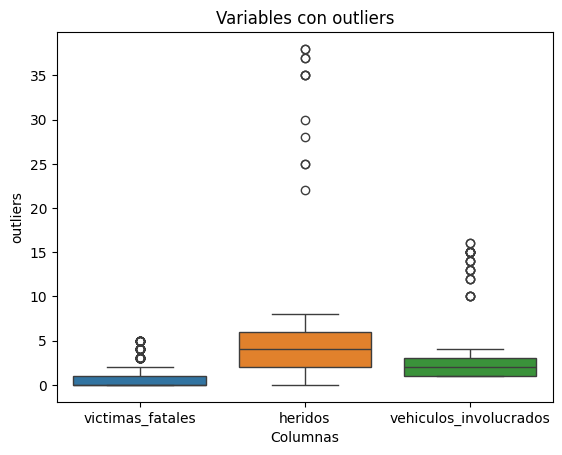

In [229]:
# Su código aquí
sns.boxplot(data=df_accidentes[['victimas_fatales', 'heridos', 'vehiculos_involucrados']])
plt.title('Variables con outliers')
plt.ylabel('outliers')
plt.xlabel('Columnas')
plt.show()

---

# PARTE 4: LIMPIEZA DE DATOS _(15 puntos)_


## 4.1 Proceso de limpieza _(11 pts)_

Aplique los siguientes pasos sobre `df_accidentes` y guarde el resultado en **`df_limpio`**:

1. **Elimine los duplicados exactos.** Imprima cuántos fueron eliminados.
2. **Impute nulos en columnas categóricas** con el valor `'Desconocido'`.
3. **Impute nulos en columnas numéricas** con la **mediana** de cada columna.
4. **Verifique** que `df_limpio` no tenga valores nulos (`isnull().sum()`).


In [230]:
# Su código aquí
# 1
df_limpio = df_accidentes.copy()

filas_antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates()
filas_despues = len(df_limpio)

print('Duplicados eliminados: ',filas_antes - filas_despues)

# 2
col_cat = df_limpio.select_dtypes(include='str')
for col in col_cat:
    if df_limpio[col].isnull().sum() > 0:
        df_limpio[col] = df_limpio[col].fillna('Desconocido')

# 3
col_num = df_limpio.select_dtypes(include='number')
for col in col_num:
    if df_limpio[col].isnull().sum() > 0:
        df_limpio[col] = df_limpio[col].fillna(col_num[col].median())

# 4
df_limpio.isnull().sum()

Duplicados eliminados:  24


id_accidente              0
fecha                     0
provincia                 0
canton                    0
tipo_accidente            0
causa_probable            0
gravedad                  0
victimas_fatales          0
heridos                   0
vehiculos_involucrados    0
condicion_climatica       0
tipo_via                  0
origen                    0
nombre_feriado            0
anio                      0
mes                       0
dia_semana                0
dtype: int64

## 4.2 Pregunta Conceptual _(4 pts)_

Para imputar valores nulos en columnas numéricas, ¿cuándo es recomendable usar:

- La **media**
- La **mediana**
- La **moda**


**✏️ Tu respuesta:**  
- La **media** se usa cuando se quiere conservar el promedio general de la variable
- La **mediana** se usa cuanado hay valores muy diferentes, como los outliers
- La **moda** se usa cuando se quiere emplear el valor más frecuente

---

# PARTE 5: EDA PROFUNDO — RESPUESTA DE PREGUNTAS _(25 puntos)_

> Use **`df_limpio`** para responder cada pregunta. Acompañe cada respuesta con una
> breve **interpretación en Markdown** (2-3 oraciones).


### Pregunta 1 _(5 pts)_

¿Cuál es el **Top 5 de provincias** con mayor número de accidentes registrados?
Muestre los resultados ordenados de mayor a menor.


In [231]:
# Su código aquí
df_limpio.groupby('provincia')['provincia'].count().sort_values(ascending=False).head(5)

provincia
Galapagos    180
Manabi       137
El Oro       113
Guayas       110
Los Rios     110
Name: provincia, dtype: int64

**✏️ Interpretación:**  
En primer lugar se muestra a Galápagos, de la región insular, con la mayor cantidad de accidentes registrados, las siguientes 4 provincias (Manabi, El Oro, Guayas y Los Rios) pertenecen a la región costa, por lo que se puede deducir que la región costera e insular tienen mayor cantidad de accidentes registrados

### Pregunta 2 _(5 pts)_

¿Cuáles son los **3 tipos de accidente más frecuentes**?
Muestre cuántos accidentes representan y el **porcentaje** sobre el total.


In [232]:
# Su código aquí
print('      ==== CANTIDAD ====')
print(df_limpio.groupby('tipo_accidente')['tipo_accidente'].count().sort_values(ascending=False).head(3))

print('\n     ==== PORCENTAJES ====')
print(round(df_limpio.groupby('tipo_accidente')['tipo_accidente'].count().sort_values(ascending=False).head(3) / len(df_limpio) * 100, 2))

      ==== CANTIDAD ====
tipo_accidente
Caida de ocupante    149
Choque frontal       149
Atropello            142
Name: tipo_accidente, dtype: int64

     ==== PORCENTAJES ====
tipo_accidente
Caida de ocupante    16.37
Choque frontal       16.37
Atropello            15.60
Name: tipo_accidente, dtype: float64


**✏️ Interpretación:**  
En primer lugar se encuentra caída del ocupante, con la misma cantidad/porcentaje en el segundo lugar está choque frontal y en tercer lugar atropello con 7 registros de diferencia en comparación a los otros dos resultados

### Pregunta 3 _(5 pts)_

¿En qué **año** ocurrieron más accidentes? ¿Y en qué **mes**?

> 💡 Use las columnas `anio` y `mes` que extrajo en la Parte 2.


In [233]:
# Su código aquí
print(f'Año: {df_limpio.groupby('anio')['provincia'].count().idxmax()}')
print(f'Mes: {df_limpio.groupby('mes')['provincia'].count().idxmax()}')

Año: 2023
Mes: 10


**✏️ Interpretación:**  
El año donde se rgistraron más accidentes fue en el _2023_, y el  _décimo_ mes (octubre)

### Pregunta 4 _(5 pts)_

¿Cuál es la **causa probable** que acumula el **mayor número total de víctimas fatales**?
Use `groupby` sobre `causa_probable` y sume `victimas_fatales`. Muestre el Top 5.


In [234]:
# Su código aquí
data_g2 = df_limpio.groupby('causa_probable')['victimas_fatales'].count().sort_values(ascending=False).head(5)
data_g2

causa_probable
Estado de embriaguez       141
Mal estado de la via       126
Exceso de velocidad        124
Cansancio del conductor    120
No respetar seniales       111
Name: victimas_fatales, dtype: int64

**✏️ Interpretación:**  
La principal causa de víctimas fatales es el estado de embriaguez con 141 fallecidos. Le siguen el mal estado de la vía y el exceso de velocidad, ambos factores de gran impacto en la seguridad vial. También destacan el cansancio del conductor y el irrespeto a las señales de tránsito, lo que evidencia que tanto la conducta de los conductores como las condiciones de las vías influyen significativamente en los accidentes.

### Pregunta 5 _(5 pts)_

Filtre los accidentes provenientes de la fuente **`'XML'`** (días festivos).

- ¿Qué porcentaje de esos accidentes fueron **Fatales**?
- ¿Difiere del porcentaje global de accidentes fatales en todo el dataset?

Muestre ambos porcentajes y compárelos.


In [235]:
# Su código aquí

# filtro
accidentes_festivos = df_limpio[df_limpio['origen'] == 'XML']

print('PORCENTAJE DE ACCIDENTES FATALES')
# 1
fatales_fest = accidentes_festivos[accidentes_festivos['gravedad'] == 'Fatal']
porcentaje_fatales_fest = len(fatales_fest)/len(accidentes_festivos)*100

print(f'> Días festivos: {round(porcentaje_fatales_fest, 2)}%')

# 2
fatales_glob = df_limpio[df_limpio['gravedad'] == 'Fatal']
porcentaje_fatales_glob = len(fatales_glob)/len(df_limpio)*100

print(f'> Global: {round(porcentaje_fatales_glob, 2)}%')

print(f'\nDiferencia: {round(porcentaje_fatales_fest - porcentaje_fatales_glob, 2)}%')

PORCENTAJE DE ACCIDENTES FATALES
> Días festivos: 16.15%
> Global: 15.49%

Diferencia: 0.66%


**✏️ Interpretación:**  
el porcentaje de accidentes fatales en días festivos supera a el porcentaje global con una diferencia del 0.66%, esta diferencia se puede dar debido a que en los días festivos es más probable que la gente salga a pasear sin imaginar que pueden verse involucradas en un accidente fatal

---

# PARTE 6: VISUALIZACIÓN CON SEABORN _(15 puntos)_

Cree un **mínimo de 3 gráficos** usando Seaborn sobre **`df_limpio`**.
Usted elige **libremente** qué visualizar, siempre que los gráficos sean **informativos**
y relevantes para el análisis de accidentes de tráfico.

**Requisitos por gráfico (5 pts c/u):**

- ✅ Título claro
- ✅ Etiquetas en los ejes (`xlabel`, `ylabel`)
- ✅ Interpretación en la celda Markdown debajo del gráfico (2-3 oraciones)

> 💡 Tipos disponibles: `countplot`, `barplot`, `histplot`, `kdeplot`, `heatmap`,
> `lineplot`, `scatterplot`, `boxplot`, `violinplot`, entre otros.

> 💡 Puede usar `plt.figure(figsize=(10,5))` antes de graficar para ajustar el tamaño.


### Gráfico 1


Text(0.5, 1.0, 'Distribución de accidentes fatales por origen')

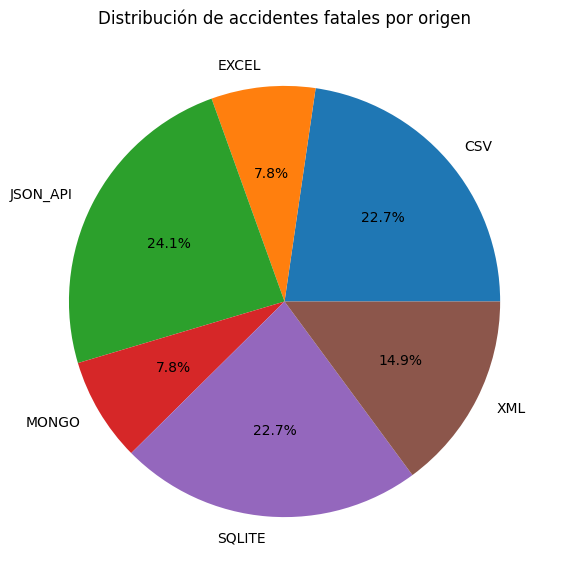

In [236]:
# Su código aquí
data_g1 = (df_limpio[df_limpio['gravedad'] == 'Fatal'].groupby('origen')['origen'].count())

plt.figure(figsize=(7,7))

plt.pie(
    data_g1,
    labels=data_g1.index,
    autopct='%1.1f%%'
)

plt.title('Distribución de accidentes fatales por origen')

**✏️ Interpretación Gráfico 1:**  
Según el gráfico, hay más accidentes fatales registrados desde `accidentes.json (JSON_API)`, que corresponde a Loja, Cotopaxi, Chimborazo y Bolívar y menos accidentes fatales registrados desde `accidentes_sierra.xlsx` (EXCEL) y `accidentes_insularMongo.json` (MONGO)

### Gráfico 2


C:\Users\User\AppData\Local\Temp\ipykernel_21244\2960567458.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Causa probable')

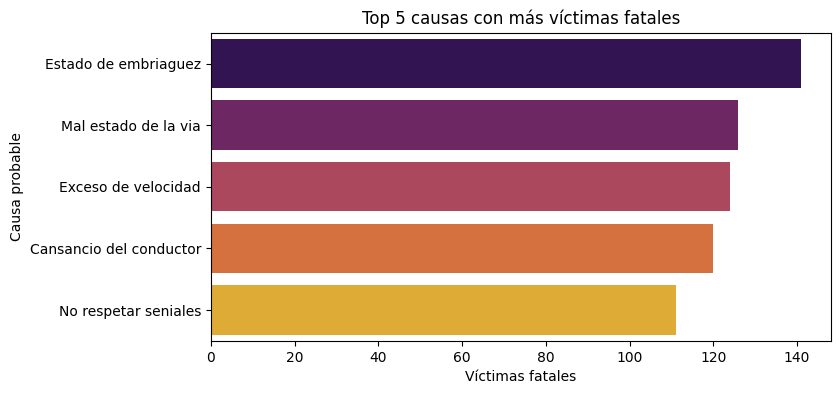

In [237]:
# Su código aquí
plt.figure(figsize=(8,4))

sns.barplot(
    x=data_g2.values,
    y=data_g2.index,
    palette='inferno'
)

plt.title('Top 5 causas con más víctimas fatales')
plt.xlabel('Víctimas fatales')
plt.ylabel('Causa probable')

**✏️ Interpretación Gráfico 2:**  
Ahora se tiene una interpretación gráfica de los datos de top 5 causas con más victimas fatales y se puede evidenciar que Estado de embriaguez tiene +140 registros relacionados

### Gráfico 3


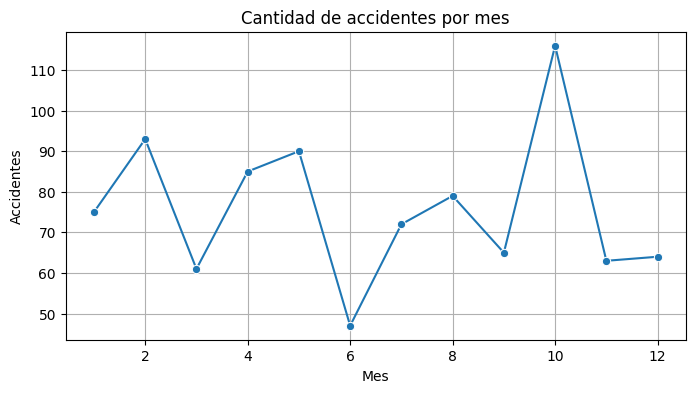

In [238]:
# Su código aquí
data_mes = (
    df_limpio.groupby('mes')
    .size()
    .reset_index(name='accidentes')
)

plt.figure(figsize=(8,4))

sns.lineplot(
    data=data_mes,
    x='mes',
    y='accidentes',
    marker='o'
)

plt.title('Cantidad de accidentes por mes')
plt.xlabel('Mes')
plt.ylabel('Accidentes')
plt.grid(True)

plt.show()

**✏️ Interpretación Gráfico 3:**  
En este gráfico podemos ver que el mes con más accidentes registrados es Octubre (10) con más de 110 casos, y el que menos accidentes registra es Junio (6) con menos de 50

---

# PARTE 7: EXPORTAR RESULTADOS A SQL SERVER _(5 puntos)_

Exporte el DataFrame **`df_limpio`**
a una tabla llamada **`resumen_accidentes_transito`** en su instancia local de SQL Server, para ello debe crear una base de datos llamada **`Accidentes`** . Luego para confirmar, extraiga los datos de dicha tabla y cargue los datos en un dataframe llamado, df_accidentes_sql_server y muestre en pantalla los primeros 50 registros.


In [239]:
import pyodbc
import urllib.parse
from sqlalchemy import create_engine

conn_str = (
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=DESKTOP-R850GIB;'
    'DATABASE=Accidentes;'
    'Trusted_Connection=yes;'
)

params = urllib.parse.quote_plus(conn_str)

engine = create_engine(
    f'mssql+pyodbc:///?odbc_connect={params}'
)

df_limpio.to_sql(
    'resumen_accidentes_transito',
    con=engine,
    schema='dbo',
    if_exists='replace',
    index=False
)

df_accidentes_sql_server = pd.read_sql(
    'select * from dbo.resumen_accidentes_transito',
    engine
)

display(df_accidentes_sql_server.head(50))

,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen,nombre_feriado,anio,mes,dia_semana
0,1.0,2019-07-11,Guayas,Daule,Choque lateral,Estado de embriaguez,Leve,0.0,4.0,1.0,Soleado,Desconocido,CSV,Desconocido,2019,7,Jueves
1,2.0,2019-07-29,Manabi,Portoviejo,Volcamiento,Distraccion del conductor,Fatal,5.0,7.0,1.0,Soleado,Autopista,CSV,Desconocido,2019,7,Lunes
2,3.0,2022-12-13,El Oro,Machala,Choque frontal,Fallas mecanicas,Grave,1.0,0.0,4.0,Lluvioso,Rural,CSV,Desconocido,2022,12,Martes
3,4.0,2022-06-01,El Oro,Pasaje,Rozamiento,Cansancio del conductor,Grave,0.0,1.0,3.0,Lluvioso,Urbana,CSV,Desconocido,2022,6,Miércoles
4,5.0,2021-04-01,Manabi,Chone,Choque frontal,No respetar seniales,Leve,0.0,4.0,2.0,Lluvioso,Autopista,CSV,Desconocido,2021,4,Jueves
5,6.0,2021-05-27,El Oro,Zaruma,Volcamiento,Mal estado de la via,Leve,0.0,7.0,4.0,Nublado,Secundaria,CSV,Desconocido,2021,5,Jueves
6,7.0,2021-02-27,Manabi,El Carmen,Rozamiento,Cansancio del conductor,Leve,0.0,2.0,1.0,Neblina,Urbana,CSV,Desconocido,2021,2,Sábado
7,8.0,2021-10-22,El Oro,Pasaje,Rozamiento,No respetar seniales,Fatal,5.0,0.0,3.0,Soleado,Autopista,CSV,Desconocido,2021,10,Viernes
8,9.0,2020-05-05,El Oro,Machala,Choque lateral,Distraccion del conductor,Grave,2.0,3.0,1.0,Soleado,Autopista,CSV,Desconocido,2020,5,Martes
9,10.0,2021-05-16,Guayas,Daule,Rozamiento,Distraccion del conductor,Grave,2.0,1.0,2.0,Lluvioso,Secundaria,CSV,Desconocido,2021,5,Domingo
